In [48]:
# Cell 1: imports and configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

# Edit this path to your local file before running
file_path = '/Users/krishnakumarjena/Downloads/CFI/Front-end Liquid Market Risk Modelling/credit_portfolio_150_bonds.xlsx'

print("File path:", file_path)

File path: /Users/krishnakumarjena/Downloads/CFI/Front-end Liquid Market Risk Modelling/credit_portfolio_150_bonds.xlsx


PHASE 1 – DATA VALIDATION & DATA UNDERSTANDING

In [49]:
# Cell 2: load data and quick preview
df = pd.read_excel(file_path)
df.columns = [str(c).strip() for c in df.columns]

# Keep only rows with Bond_ID
if "Bond_ID" not in df.columns:
    raise ValueError("Bond_ID column not found. Check the Excel header row.")
df = df[df["Bond_ID"].notna()].reset_index(drop=True)

# Coerce numeric columns
num_cols = ["Position","Price","Duration","Spread_bps","Yield","Maturity_Years",
            "Daily_Return","Benchmark_Return","Market_Value","Portfolio_Weight","Benchmark_Weight"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rows loaded:", len(df))
display(df.head(8))
print("Columns:", df.columns.tolist())

Rows loaded: 150


,Bond_ID,Issuer,Sector,Industry,Rating,Country,Position,Price,Duration,Spread_bps,Yield,Maturity_Years,Daily_Return,Benchmark_Return,Market_Value,Portfolio_Weight,Benchmark_Weight
0,BOND_0001,Standard Industries,Technology,Semiconductors,BBB,US,17907098.37,95.5356,2.87,143.59,5.8746,4.30,-0.003682,0.007743,1.710765e+07,0.011304,0.002155
1,BOND_0002,Premier Manufacturing,Consumer,Consumer Products,AA,Japan,11749625.75,97.5659,4.54,71.56,4.7948,18.44,-0.010751,0.000158,1.146363e+07,0.007575,0.017750
2,BOND_0003,Vanguard Inc,Technology,Hardware,BB,Australia,14899759.58,99.1754,9.79,424.15,7.9560,14.54,-0.001453,0.007149,1.477690e+07,0.009764,0.007590
3,BOND_0004,Global Enterprises,Industrials,Aerospace,BBB,UK,12402891.01,103.0383,1.61,176.84,6.3733,17.17,-0.000522,0.004286,1.277973e+07,0.008444,0.004615
4,BOND_0005,Horizon Capital,Energy,Midstream,BBB,UK,10200565.43,95.1312,5.77,184.75,5.1008,17.55,-0.003991,0.002599,9.703920e+06,0.006412,0.000086
5,BOND_0006,Consolidated Energy,Technology,Hardware,AA,UK,1264133.37,108.4162,3.35,74.64,4.3483,12.11,0.004089,-0.000151,1.370525e+06,0.000906,0.032878
6,BOND_0007,National International,Technology,Hardware,A,Germany,17506416.22,85.4528,2.38,110.47,5.1115,13.12,0.001375,0.005480,1.495972e+07,0.009885,0.007497
7,BOND_0008,Zenith Industries,Energy,Midstream,B,Japan,8662322.12,88.3451,2.59,690.96,8.7457,9.94,0.003596,0.009974,7.652737e+06,0.005057,0.002567


Columns: ['Bond_ID', 'Issuer', 'Sector', 'Industry', 'Rating', 'Country', 'Position', 'Price', 'Duration', 'Spread_bps', 'Yield', 'Maturity_Years', 'Daily_Return', 'Benchmark_Return', 'Market_Value', 'Portfolio_Weight', 'Benchmark_Weight']


In [50]:
# Cell 3: Portfolio summary and data quality checks
summary = {
    "Number of Bonds": len(df),
    "Total Market Value": df["Market_Value"].sum() if "Market_Value" in df.columns else np.nan,
    "Average Duration": df["Duration"].mean() if "Duration" in df.columns else np.nan,
    "Average Yield": df["Yield"].mean() if "Yield" in df.columns else np.nan,
    "Average Spread (bps)": df["Spread_bps"].mean() if "Spread_bps" in df.columns else np.nan
}
print("Portfolio Summary:")
for k,v in summary.items():
    print(f" - {k}: {v}")

# Data quality
missing = df.isnull().sum()
duplicates = df["Bond_ID"].duplicated().sum()
pw_sum = df["Portfolio_Weight"].sum() if "Portfolio_Weight" in df.columns else np.nan
bw_sum = df["Benchmark_Weight"].sum() if "Benchmark_Weight" in df.columns else np.nan

print("\nData Quality Checks:")
print(" - Missing values per column:")
display(missing)
print(" - Duplicate Bond_ID count:", duplicates)
print(" - Portfolio Weight sum (raw):", pw_sum)
print(" - Benchmark Weight sum (raw):", bw_sum)

# Detect weight scale and normalize to decimals if needed (no file writes)
if "Portfolio_Weight" in df.columns:
    if 90 <= pw_sum <= 110:
        df["Portfolio_Weight"] = df["Portfolio_Weight"] / 100.0
        print("Converted Portfolio_Weight from percent to decimal.")
if "Benchmark_Weight" in df.columns:
    if 90 <= bw_sum <= 110:
        df["Benchmark_Weight"] = df["Benchmark_Weight"] / 100.0
        print("Converted Benchmark_Weight from percent to decimal.")

Portfolio Summary:
 - Number of Bonds: 150
 - Total Market Value: 1513379841.587677
 - Average Duration: 4.9858666666666664
 - Average Yield: 6.019940666666667
 - Average Spread (bps): 218.58860000000004

Data Quality Checks:
 - Missing values per column:


Bond_ID             0
Issuer              0
Sector              0
Industry            0
Rating              0
Country             0
Position            0
Price               0
Duration            0
Spread_bps          0
Yield               0
Maturity_Years      0
Daily_Return        0
Benchmark_Return    0
Market_Value        0
Portfolio_Weight    0
Benchmark_Weight    0
dtype: int64

 - Duplicate Bond_ID count: 0
 - Portfolio Weight sum (raw): 0.9999999999999982
 - Benchmark Weight sum (raw): 0.999999999999998


PHASE 2 – PORTFOLIO CONSTRUCTION ANALYTICS

In [51]:
# Cell 4: exposures and top holdings (no saving)
# Standardize Rating and Sector strings
if "Rating" in df.columns:
    df["Rating"] = df["Rating"].astype(str).str.strip().str.upper()
if "Sector" in df.columns:
    df["Sector"] = df["Sector"].astype(str).str.strip()
if "Country" in df.columns:
    df["Country"] = df["Country"].astype(str).str.strip()

# Sector exposure (selected sectors)
sectors_of_interest = ["Financials","Technology","Energy","Healthcare","Industrials","Consumer"]
sector_all = df.groupby("Sector").agg(
    Market_Value=("Market_Value","sum"),
    Portfolio_Weight=("Portfolio_Weight","sum")
).sort_values("Market_Value", ascending=False)
sector_selected = sector_all.reindex(sectors_of_interest).fillna(0)

# Rating exposure ordered
rating_order = ["AAA","AA","A","BBB","BB","B","CCC"]
rating = df.groupby("Rating").agg(
    Market_Value=("Market_Value","sum"),
    Portfolio_Weight=("Portfolio_Weight","sum")
).reindex(rating_order).fillna(0)

# Country exposure
country = df.groupby("Country").agg(
    Market_Value=("Market_Value","sum"),
    Portfolio_Weight=("Portfolio_Weight","sum")
).sort_values("Market_Value", ascending=False)

# Top 10 holdings
top10 = df.sort_values("Market_Value", ascending=False).head(10)[
    ["Bond_ID","Issuer","Sector","Rating","Country","Market_Value","Portfolio_Weight"]
].reset_index(drop=True)

print("Sector exposure (selected):")
display(sector_selected)
print("\nRating exposure (ordered):")
display(rating)
print("\nTop 15 countries by Market Value:")
display(country.head(15))
print("\nTop 10 holdings by Market Value:")
display(top10)

Sector exposure (selected):


,Market_Value,Portfolio_Weight
Sector,,
Financials,3.528228e+08,0.233136
Technology,2.850567e+08,0.188358
Energy,2.438034e+08,0.161099
Healthcare,2.867079e+08,0.189449
Industrials,2.174966e+08,0.143716
Consumer,1.274924e+08,0.084243



Rating exposure (ordered):


,Market_Value,Portfolio_Weight
Rating,,
AAA,1.542951e+08,0.101954
AA,2.386176e+08,0.157672
A,3.095573e+08,0.204547
BBB,3.677984e+08,0.243031
BB,2.813516e+08,0.185909
B,1.198408e+08,0.079188
CCC,4.191902e+07,0.027699



Top 15 countries by Market Value:


,Market_Value,Portfolio_Weight
Country,,
US,2.692430e+08,0.177908
UK,2.425739e+08,0.160286
Canada,2.339343e+08,0.154577
Australia,2.269357e+08,0.149953
Germany,1.957297e+08,0.129333
Japan,1.840537e+08,0.121618
France,1.609096e+08,0.106325



Top 10 holdings by Market Value:


,Bond_ID,Issuer,Sector,Rating,Country,Market_Value,Portfolio_Weight
0,BOND_0104,First Enterprises,Financials,BBB,UK,2.063095e+07,0.013632
1,BOND_0028,Strategic Group,Technology,B,Germany,2.052585e+07,0.013563
2,BOND_0124,Summit Systems,Healthcare,BBB,Canada,2.051652e+07,0.013557
3,BOND_0122,Pioneer Ventures,Financials,A,Canada,2.007932e+07,0.013268
4,BOND_0015,Advanced Group,Energy,AA,US,1.978971e+07,0.013076
5,BOND_0123,Liberty Financial,Energy,A,Australia,1.941264e+07,0.012827
6,BOND_0070,Consolidated Technologies,Financials,BBB,Australia,1.831664e+07,0.012103
7,BOND_0032,United Corp,Consumer,AA,Canada,1.825886e+07,0.012065
8,BOND_0077,Prime Manufacturing,Financials,CCC,US,1.810354e+07,0.011962
9,BOND_0106,Alliance Industries,Financials,AAA,US,1.796778e+07,0.011873


/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/2594226918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_all.reset_index().head(12), x="Market_Value", y="Sector", palette="muted")


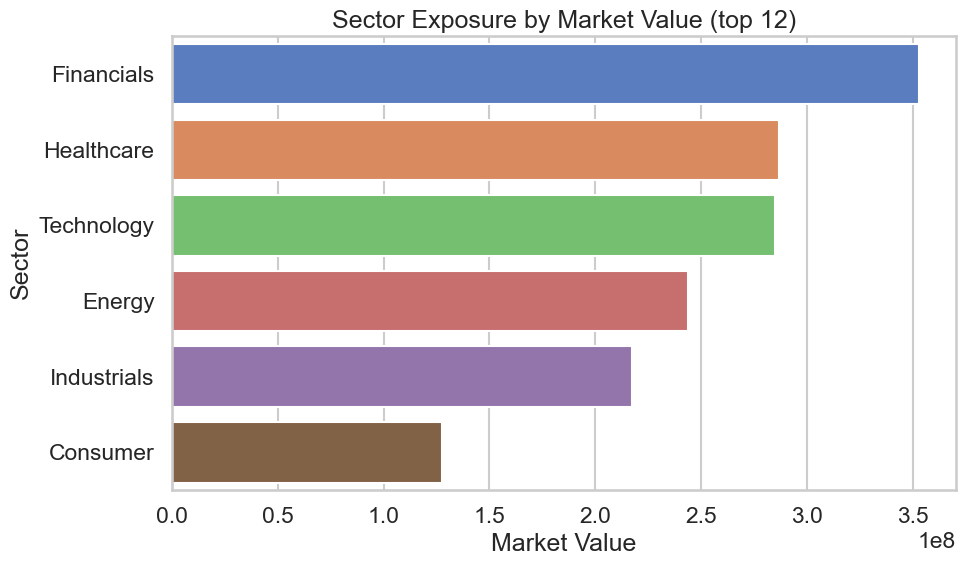

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/2594226918.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating.reset_index(), x="Rating", y="Market_Value", palette="coolwarm")


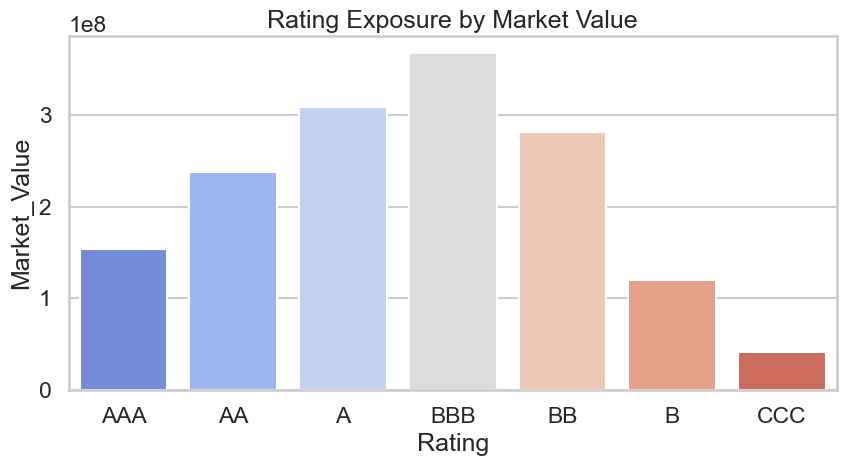

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/2594226918.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country.reset_index().head(10), x="Market_Value", y="Country", palette="viridis")


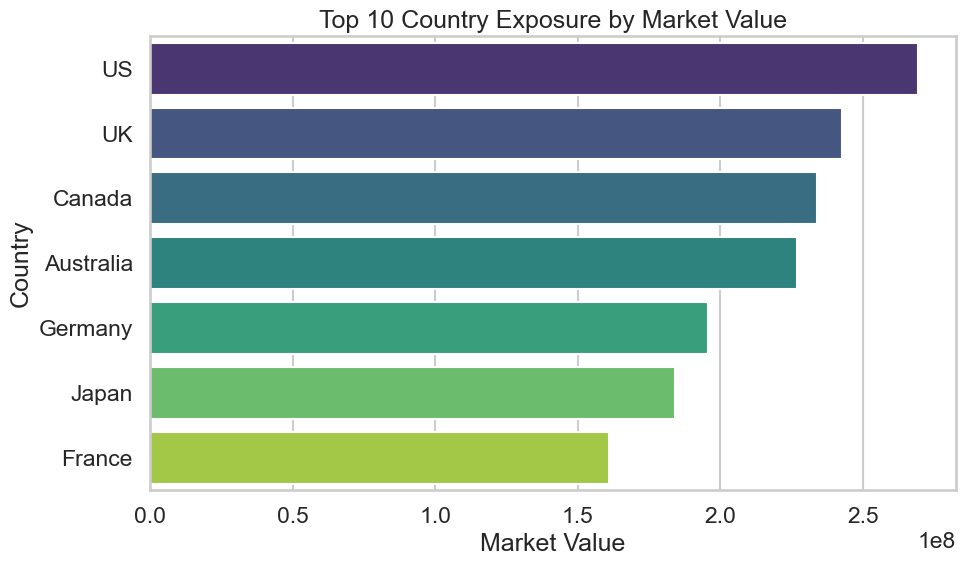

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/2594226918.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Market_Value", y="Bond_ID", palette="magma")


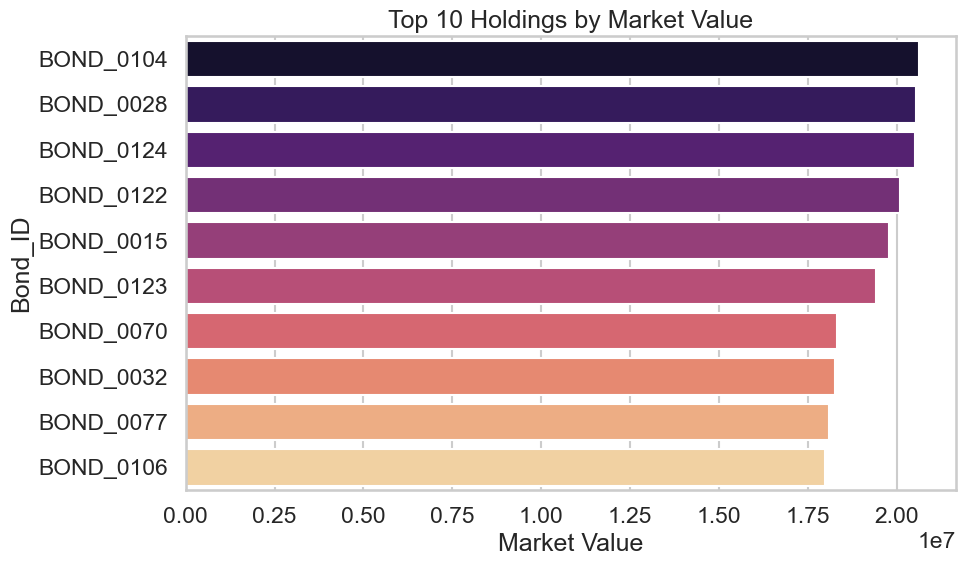

In [52]:
# Cell 5: charts inline (no saving)
plt.figure(figsize=(10,6))
sns.barplot(data=sector_all.reset_index().head(12), x="Market_Value", y="Sector", palette="muted")
plt.title("Sector Exposure by Market Value (top 12)")
plt.xlabel("Market Value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
sns.barplot(data=rating.reset_index(), x="Rating", y="Market_Value", palette="coolwarm")
plt.title("Rating Exposure by Market Value")
plt.xlabel("Rating")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=country.reset_index().head(10), x="Market_Value", y="Country", palette="viridis")
plt.title("Top 10 Country Exposure by Market Value")
plt.xlabel("Market Value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="Market_Value", y="Bond_ID", palette="magma")
plt.title("Top 10 Holdings by Market Value")
plt.xlabel("Market Value")
plt.tight_layout()
plt.show()


In [53]:
# Cell 6: compute active weights at bond level
if "Portfolio_Weight" not in df.columns or "Benchmark_Weight" not in df.columns:
    raise ValueError("Portfolio_Weight and/or Benchmark_Weight column missing. Provide or compute them before running active analytics.")

df["Active_Weight"] = df["Portfolio_Weight"] - df["Benchmark_Weight"]

print("Portfolio weight sum (raw):", df["Portfolio_Weight"].sum())
print("Benchmark weight sum (raw):", df["Benchmark_Weight"].sum())

print("\nTop 10 largest positive active weights (overweights):")
display(df.sort_values("Active_Weight", ascending=False).head(10)[
    ["Bond_ID","Issuer","Sector","Rating","Country","Portfolio_Weight","Benchmark_Weight","Active_Weight","Market_Value"]
])

print("\nTop 10 largest negative active weights (underweights):")
display(df.sort_values("Active_Weight", ascending=True).head(10)[
    ["Bond_ID","Issuer","Sector","Rating","Country","Portfolio_Weight","Benchmark_Weight","Active_Weight","Market_Value"]
])

Portfolio weight sum (raw): 0.9999999999999982
Benchmark weight sum (raw): 0.999999999999998

Top 10 largest positive active weights (overweights):


,Bond_ID,Issuer,Sector,Rating,Country,Portfolio_Weight,Benchmark_Weight,Active_Weight,Market_Value
103,BOND_0104,First Enterprises,Financials,BBB,UK,0.013632,0.000879,0.012753,2.063095e+07
121,BOND_0122,Pioneer Ventures,Financials,A,Canada,0.013268,0.001528,0.011740,2.007932e+07
141,BOND_0142,United Holdings,Healthcare,BBB,Canada,0.011055,0.000344,0.010711,1.673101e+07
76,BOND_0077,Prime Manufacturing,Financials,CCC,US,0.011962,0.001323,0.010639,1.810354e+07
85,BOND_0086,Crest Enterprises,Technology,AA,Canada,0.011297,0.000741,0.010557,1.709715e+07
105,BOND_0106,Alliance Industries,Financials,AAA,US,0.011873,0.001812,0.010061,1.796778e+07
68,BOND_0069,Horizon Financial,Financials,A,France,0.010788,0.000897,0.009891,1.632580e+07
0,BOND_0001,Standard Industries,Technology,BBB,US,0.011304,0.002155,0.009150,1.710765e+07
133,BOND_0134,Prime Group,Financials,B,Australia,0.010864,0.001721,0.009143,1.644141e+07
27,BOND_0028,Strategic Group,Technology,B,Germany,0.013563,0.004514,0.009049,2.052585e+07



Top 10 largest negative active weights (underweights):


,Bond_ID,Issuer,Sector,Rating,Country,Portfolio_Weight,Benchmark_Weight,Active_Weight,Market_Value
5,BOND_0006,Consolidated Energy,Technology,AA,UK,0.000906,0.032878,-0.031972,1.370525e+06
117,BOND_0118,Metro Capital,Consumer,CCC,UK,0.008734,0.031821,-0.023087,1.321742e+07
13,BOND_0014,National Pharma,Healthcare,AAA,Japan,0.002867,0.025828,-0.022961,4.339070e+06
98,BOND_0099,Prime Financial,Energy,BB,UK,0.006465,0.027046,-0.020581,9.784011e+06
120,BOND_0121,Summit Capital,Energy,BBB,UK,0.001339,0.020219,-0.018880,2.026246e+06
138,BOND_0139,Dynamic Financial,Energy,BBB,Canada,0.000661,0.018658,-0.017997,1.000030e+06
123,BOND_0124,Summit Systems,Healthcare,BBB,Canada,0.013557,0.026230,-0.012673,2.051652e+07
26,BOND_0027,Premier Capital,Financials,BB,Germany,0.010054,0.022603,-0.012550,1.521506e+07
47,BOND_0048,Royal Manufacturing,Industrials,B,Germany,0.001775,0.014270,-0.012495,2.685616e+06
44,BOND_0045,First Industries,Consumer,AAA,US,0.002809,0.014362,-0.011553,4.251533e+06


In [54]:
# Cell 7: sector and rating active exposure
sector_active = df.groupby("Sector").agg(
    Market_Value=("Market_Value","sum"),
    Portfolio_Weight=("Portfolio_Weight","sum"),
    Benchmark_Weight=("Benchmark_Weight","sum"),
    Active_Weight=("Active_Weight","sum")
).sort_values("Active_Weight", ascending=False)

rating_order = ["AAA","AA","A","BBB","BB","B","CCC"]
rating_active = df.groupby("Rating").agg(
    Market_Value=("Market_Value","sum"),
    Portfolio_Weight=("Portfolio_Weight","sum"),
    Benchmark_Weight=("Benchmark_Weight","sum"),
    Active_Weight=("Active_Weight","sum")
).reindex(rating_order).fillna(0)

print("Sector active exposure (sorted):")
display(sector_active)
print("\nRating active exposure (ordered):")
display(rating_active)

Sector active exposure (sorted):


,Market_Value,Portfolio_Weight,Benchmark_Weight,Active_Weight
Sector,,,,
Financials,3.528228e+08,0.233136,0.154707,0.078428
Industrials,2.174966e+08,0.143716,0.096465,0.047251
Healthcare,2.867079e+08,0.189449,0.211719,-0.022270
Energy,2.438034e+08,0.161099,0.183786,-0.022687
Technology,2.850567e+08,0.188358,0.215122,-0.026765
Consumer,1.274924e+08,0.084243,0.138200,-0.053957



Rating active exposure (ordered):


,Market_Value,Portfolio_Weight,Benchmark_Weight,Active_Weight
Rating,,,,
AAA,1.542951e+08,0.101954,0.131322,-0.029368
AA,2.386176e+08,0.157672,0.186867,-0.029195
A,3.095573e+08,0.204547,0.183384,0.021163
BBB,3.677984e+08,0.243031,0.209234,0.033797
BB,2.813516e+08,0.185909,0.184846,0.001063
B,1.198408e+08,0.079188,0.055030,0.024157
CCC,4.191902e+07,0.027699,0.049316,-0.021617


/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/1961731536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_plot, x="Active_Weight", y="Sector", palette="coolwarm")


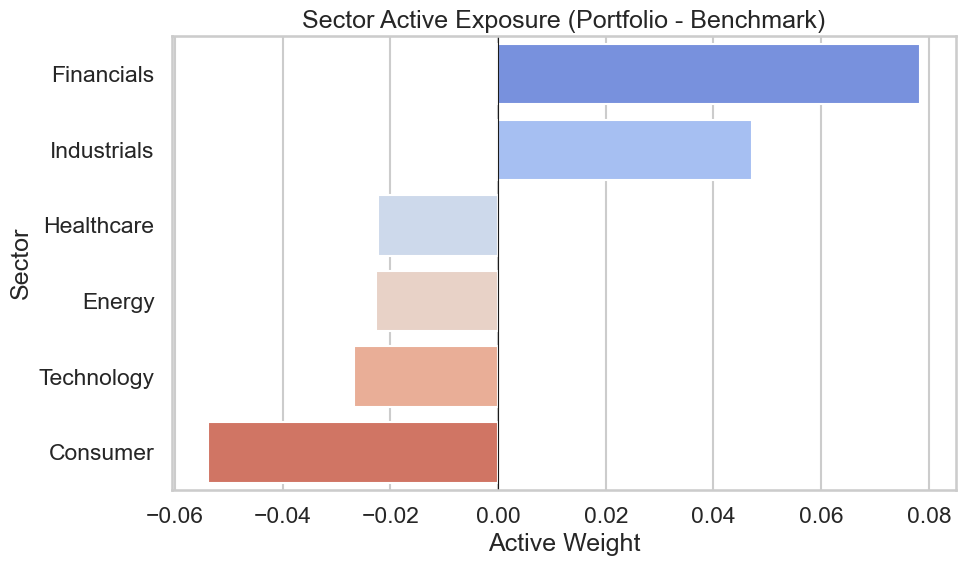

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/1961731536.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_plot, x="Active_Weight", y="Rating", palette="coolwarm")


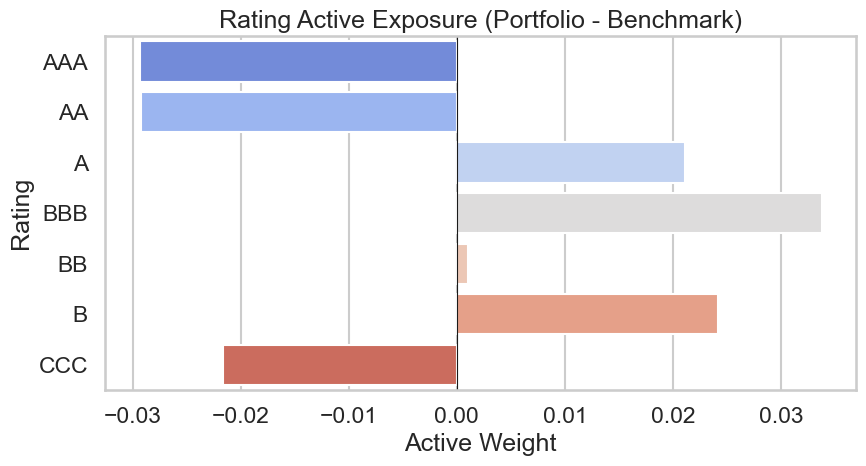

In [55]:
# Cell 8: charts for active exposures (inline)
sector_plot = sector_active.reset_index().sort_values("Active_Weight", ascending=False).head(12)
plt.figure(figsize=(10,6))
sns.barplot(data=sector_plot, x="Active_Weight", y="Sector", palette="coolwarm")
plt.axvline(0, color="k", linewidth=0.8)
plt.title("Sector Active Exposure (Portfolio - Benchmark)")
plt.xlabel("Active Weight")
plt.tight_layout()
plt.show()

rating_plot = rating_active.reset_index()
plt.figure(figsize=(9,5))
sns.barplot(data=rating_plot, x="Active_Weight", y="Rating", palette="coolwarm")
plt.axvline(0, color="k", linewidth=0.8)
plt.title("Rating Active Exposure (Portfolio - Benchmark)")
plt.xlabel("Active Weight")
plt.tight_layout()
plt.show()

PHASE 4 – RISK ANALYTICS

In [56]:
# Cell 9: prepare dollar-duration and spread primitives
if "Market_Value" not in df.columns or "Duration" not in df.columns:
    raise ValueError("Market_Value and/or Duration column missing for risk analytics.")

df["Dollar_Duration"] = df["Market_Value"] * df["Duration"]

if "Spread_bps" in df.columns:
    df["Spread_pct"] = df["Spread_bps"] / 10000.0
else:
    df["Spread_pct"] = np.nan

portfolio_duration = df["Dollar_Duration"].sum() / df["Market_Value"].sum()
print("Portfolio Duration (market-weighted):", round(portfolio_duration,4))

Portfolio Duration (market-weighted): 4.882


In [57]:
# Show the new primitives alongside key bond info
primitives_table = df[[
    "Bond_ID", 
    "Rating", 
    "Sector", 
    "Market_Value", 
    "Duration", 
    "Dollar_Duration", 
    "Spread_bps", 
    "Spread_pct",
    "Yield"
]].sort_values("Dollar_Duration", ascending=False).copy()

for col in ["Market_Value", "Dollar_Duration"]:
    primitives_table[col] = primitives_table[col].apply(lambda x: f"{x:,.0f}")

display(primitives_table.head(15))

,Bond_ID,Rating,Sector,Market_Value,Duration,Dollar_Duration,Spread_bps,Spread_pct,Yield
14,BOND_0015,AA,Energy,"19,789,706",9.95,"196,907,579",53.98,0.005398,4.8835
122,BOND_0123,A,Energy,"19,412,641",9.37,"181,896,449",147.20,0.014720,4.6243
103,BOND_0104,BBB,Financials,"20,630,951",8.25,"170,205,347",198.42,0.019842,6.2103
121,BOND_0122,A,Financials,"20,079,318",8.32,"167,059,927",83.01,0.008301,5.4109
31,BOND_0032,AA,Consumer,"18,258,858",8.94,"163,234,193",53.94,0.005394,4.7004
82,BOND_0083,AA,Technology,"16,982,415",8.80,"149,445,249",61.30,0.006130,4.2226
2,BOND_0003,BB,Technology,"14,776,896",9.79,"144,665,813",424.15,0.042415,7.9560
94,BOND_0095,B,Financials,"16,724,429",8.36,"139,816,230",669.49,0.066949,10.6042
97,BOND_0098,AAA,Financials,"16,737,789",7.26,"121,516,350",33.04,0.003304,3.7202
65,BOND_0066,A,Healthcare,"12,274,188",9.72,"119,305,104",120.35,0.012035,5.1957


In [70]:
# Duration risk contribution
total_dollar_duration = df["Dollar_Duration"].sum()
df["Duration_Risk_Contribution"] = df["Dollar_Duration"] / total_dollar_duration

# Spread risk contribution (proxy)
df["Spread_Exposure"] = df["Market_Value"] * df["Spread_pct"]
total_spread_exposure = df["Spread_Exposure"].sum()
df["Spread_Risk_Contribution"] = df["Spread_Exposure"] / (total_spread_exposure if total_spread_exposure != 0 else 1)

# Top bond contributors
top_duration_bonds = df.sort_values("Duration_Risk_Contribution", ascending=False).head(10)[
    ["Bond_ID", "Issuer", "Sector", "Rating", "Market_Value", "Duration", "Dollar_Duration", "Duration_Risk_Contribution"]
].copy()

top_spread_bonds = df.sort_values("Spread_Risk_Contribution", ascending=False).head(10)[
    ["Bond_ID", "Issuer", "Sector", "Rating", "Market_Value", "Spread_bps", "Spread_Risk_Contribution"]
].copy()

# Format all numeric columns to avoid scientific notation
for col in ["Market_Value", "Dollar_Duration"]:
    top_duration_bonds[col] = top_duration_bonds[col].apply(lambda x: f"{x:,.0f}")
top_duration_bonds["Duration_Risk_Contribution"] = top_duration_bonds["Duration_Risk_Contribution"].apply(lambda x: f"{x:.4%}")

for col in ["Market_Value"]:
    top_spread_bonds[col] = top_spread_bonds[col].apply(lambda x: f"{x:,.0f}")
top_spread_bonds["Spread_Risk_Contribution"] = top_spread_bonds["Spread_Risk_Contribution"].apply(lambda x: f"{x:.4%}")

print("Top 10 bonds by Duration Risk Contribution:")
display(top_duration_bonds)
print("\nTop 10 bonds by Spread Risk Contribution:")
display(top_spread_bonds)

# Sector-level risk
sector_risk = df.groupby("Sector").agg(
    Sector_Market_Value=("Market_Value", "sum"),
    Sector_Dollar_Duration=("Dollar_Duration", "sum"),
    Sector_Spread_Exposure=("Spread_Exposure", "sum")
).copy()

sector_risk["Duration_Risk_Share"] = sector_risk["Sector_Dollar_Duration"] / total_dollar_duration
sector_risk["Spread_Risk_Share"] = sector_risk["Sector_Spread_Exposure"] / (total_spread_exposure if total_spread_exposure != 0 else 1)

# Format ALL dollar columns to avoid scientific notation
for col in ["Sector_Market_Value", "Sector_Dollar_Duration", "Sector_Spread_Exposure"]:
    sector_risk[col] = sector_risk[col].apply(lambda x: f"{x:,.0f}")
sector_risk["Duration_Risk_Share"] = sector_risk["Duration_Risk_Share"].apply(lambda x: f"{x:.4%}")
sector_risk["Spread_Risk_Share"] = sector_risk["Spread_Risk_Share"].apply(lambda x: f"{x:.4%}")

print("\nSector risk contribution (duration & spread shares):")
display(sector_risk.sort_values("Duration_Risk_Share", ascending=False))

Top 10 bonds by Duration Risk Contribution:


,Bond_ID,Issuer,Sector,Rating,Market_Value,Duration,Dollar_Duration,Duration_Risk_Contribution
14,BOND_0015,Advanced Group,Energy,AA,"19,789,706",9.95,"196,907,579",2.6651%
122,BOND_0123,Liberty Financial,Energy,A,"19,412,641",9.37,"181,896,449",2.4619%
103,BOND_0104,First Enterprises,Financials,BBB,"20,630,951",8.25,"170,205,347",2.3037%
121,BOND_0122,Pioneer Ventures,Financials,A,"20,079,318",8.32,"167,059,927",2.2611%
31,BOND_0032,United Corp,Consumer,AA,"18,258,858",8.94,"163,234,193",2.2093%
82,BOND_0083,Eastern Systems,Technology,AA,"16,982,415",8.80,"149,445,249",2.0227%
2,BOND_0003,Vanguard Inc,Technology,BB,"14,776,896",9.79,"144,665,813",1.9580%
94,BOND_0095,Eastern Resources,Financials,B,"16,724,429",8.36,"139,816,230",1.8924%
97,BOND_0098,Royal Corp,Financials,AAA,"16,737,789",7.26,"121,516,350",1.6447%
65,BOND_0066,Southern Capital,Healthcare,A,"12,274,188",9.72,"119,305,104",1.6148%



Top 10 bonds by Spread Risk Contribution:


,Bond_ID,Issuer,Sector,Rating,Market_Value,Spread_bps,Spread_Risk_Contribution
76,BOND_0077,Prime Manufacturing,Financials,CCC,"18,103,536",1184.24,6.3631%
117,BOND_0118,Metro Capital,Consumer,CCC,"13,217,419",1183.93,4.6445%
27,BOND_0028,Strategic Group,Technology,B,"20,525,847",564.86,3.4412%
94,BOND_0095,Eastern Resources,Financials,B,"16,724,429",669.49,3.3233%
143,BOND_0144,Crest Partners,Healthcare,CCC,"10,598,070",999.27,3.1432%
133,BOND_0134,Prime Group,Financials,B,"16,441,406",613.93,2.9959%
130,BOND_0131,Global Inc,Healthcare,B,"13,481,625",675.44,2.7027%
10,BOND_0011,Standard International,Industrials,BB,"17,680,468",431.81,2.2660%
40,BOND_0041,Heritage Industries,Industrials,B,"10,913,276",693.97,2.2478%
35,BOND_0036,Liberty Holdings,Financials,B,"13,981,668",524.13,2.1750%



Sector risk contribution (duration & spread shares):


,Sector_Market_Value,Sector_Dollar_Duration,Sector_Spread_Exposure,Duration_Risk_Share,Spread_Risk_Share
Sector,,,,,
Consumer,"127,492,375","593,159,712","2,806,552",8.0283%,8.3299%
Financials,"352,822,832","1,776,225,704","9,425,713",24.0408%,27.9758%
Energy,"243,803,418","1,478,796,982","4,468,350",20.0151%,13.2622%
Healthcare,"286,707,923","1,360,718,466","6,173,701",18.4170%,18.3238%
Technology,"285,056,705","1,183,965,305","5,986,272",16.0247%,17.7675%
Industrials,"217,496,589","995,524,959","4,831,736",13.4742%,14.3408%


/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/1571592064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_plot, x="Duration_Risk_Share", y="Sector", palette="coolwarm")


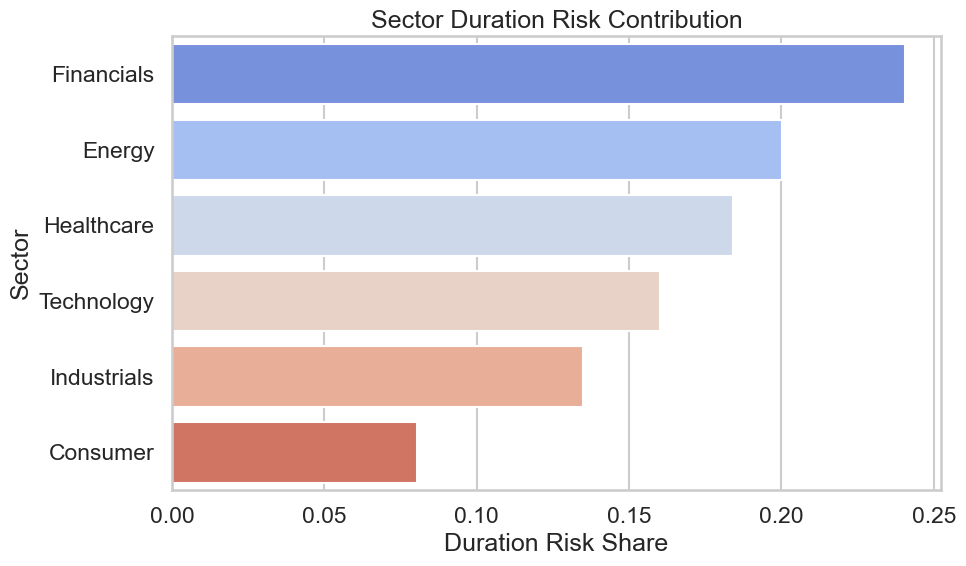

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/1571592064.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_plot2, x="Spread_Risk_Share", y="Sector", palette="viridis")


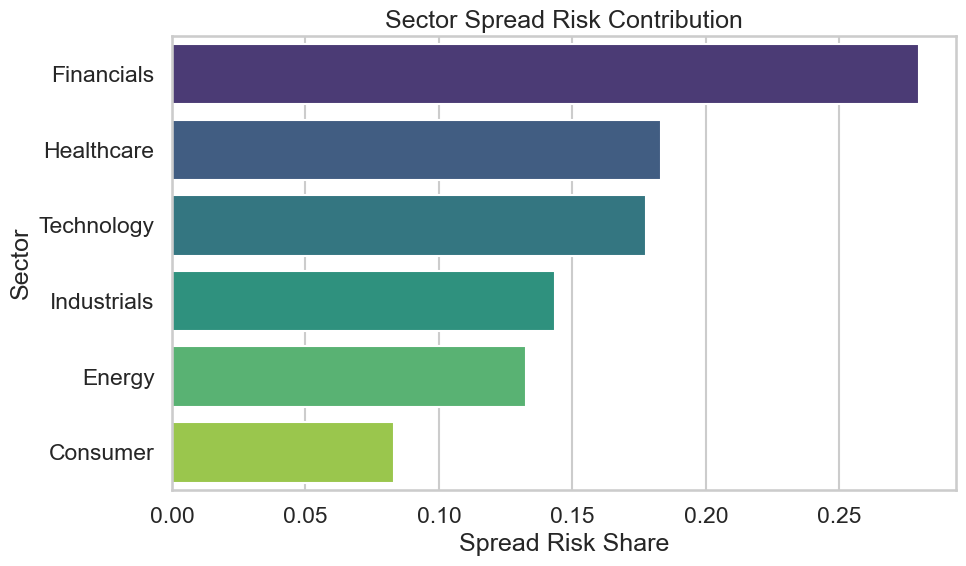

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/1571592064.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_combined.sort_values("Combined_Risk_Score", ascending=False).head(10), x="Combined_Risk_Score", y="Bond_ID", palette="magma")


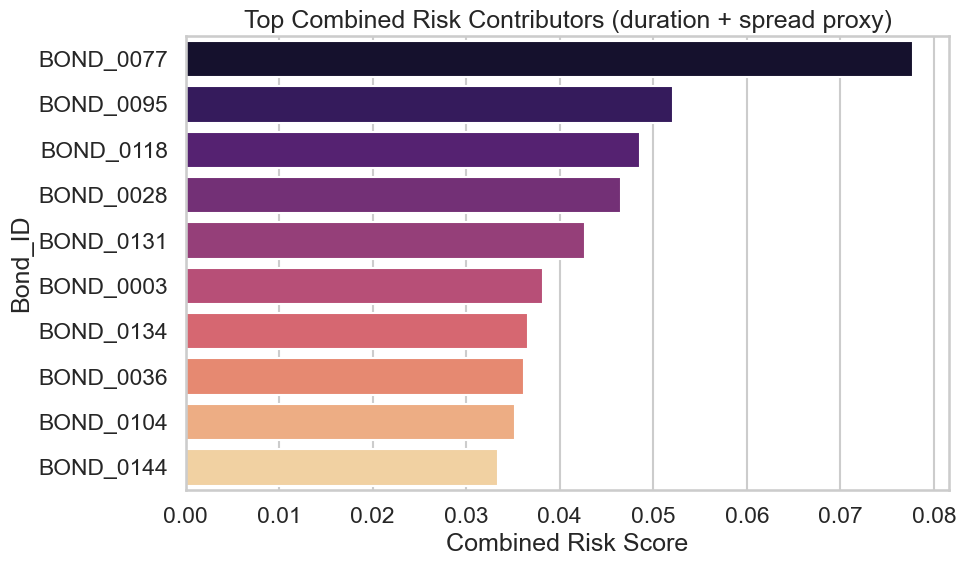

In [59]:
# Cell 11: risk contribution charts (inline)
plt.figure(figsize=(10,6))
sector_plot = sector_risk.reset_index().sort_values("Duration_Risk_Share", ascending=False).head(12)
sns.barplot(data=sector_plot, x="Duration_Risk_Share", y="Sector", palette="coolwarm")
plt.title("Sector Duration Risk Contribution")
plt.xlabel("Duration Risk Share")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sector_plot2 = sector_risk.reset_index().sort_values("Spread_Risk_Share", ascending=False).head(12)
sns.barplot(data=sector_plot2, x="Spread_Risk_Share", y="Sector", palette="viridis")
plt.title("Sector Spread Risk Contribution")
plt.xlabel("Spread Risk Share")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
top_combined = df.copy()
top_combined["Combined_Risk_Score"] = (top_combined["Dollar_Duration"] / top_combined["Dollar_Duration"].sum()) + (top_combined["Spread_Exposure"] / (top_combined["Spread_Exposure"].sum() if top_combined["Spread_Exposure"].sum()!=0 else 1))
sns.barplot(data=top_combined.sort_values("Combined_Risk_Score", ascending=False).head(10), x="Combined_Risk_Score", y="Bond_ID", palette="magma")
plt.title("Top Combined Risk Contributors (duration + spread proxy)")
plt.xlabel("Combined Risk Score")
plt.tight_layout()
plt.show()

PHASE 5 – STRESS TESTING

In [60]:
# Cell 12: prepare primitives for stress testing
# Ensure Duration and Market_Value exist (used as sensitivity proxy)
if "Duration" not in df.columns or "Market_Value" not in df.columns:
    raise ValueError("Duration and Market_Value required for stress testing.")

# Dollar duration already computed in Phase 4
# Define scenarios
scenarios = {
    "Rates_+50bps": {"type":"rates", "delta_bps":50},
    "Rates_+100bps": {"type":"rates", "delta_bps":100},
    "IG_Spread_+25bps": {"type":"spread_ig", "delta_bps":25},
    "HY_Spread_+100bps": {"type":"spread_hy", "delta_bps":100}
}
ig_ratings = ["AAA","AA","A","BBB"]
hy_ratings = ["BB","B","CCC"]

def compute_loss_using_duration(mv, duration, delta_bps):
    delta = delta_bps / 10000.0
    dollar_duration = mv * duration
    loss = dollar_duration * delta
    return loss

loss_tables = {}
for name, s in scenarios.items():
    if s["type"] == "rates":
        df[name + "_Loss"] = df.apply(lambda r: compute_loss_using_duration(r["Market_Value"], r["Duration"], s["delta_bps"]), axis=1)
    elif s["type"] == "spread_ig":
        df[name + "_Loss"] = df.apply(lambda r: compute_loss_using_duration(r["Market_Value"], r["Duration"], s["delta_bps"]) if r["Rating"] in ig_ratings else 0.0, axis=1)
    elif s["type"] == "spread_hy":
        df[name + "_Loss"] = df.apply(lambda r: compute_loss_using_duration(r["Market_Value"], r["Duration"], s["delta_bps"]) if r["Rating"] in hy_ratings else 0.0, axis=1)
    loss_tables[name] = df[[ "Bond_ID","Issuer","Sector","Rating","Market_Value", name + "_Loss"]].copy()

portfolio_losses = {name: loss_tables[name][name + "_Loss"].sum() for name in loss_tables}
print("Portfolio loss (absolute) by scenario:")
for k,v in portfolio_losses.items():
    print(f"  {k}: {v:,.2f}")

Portfolio loss (absolute) by scenario:
  Rates_+50bps: 36,941,955.64
  Rates_+100bps: 73,883,911.29
  IG_Spread_+25bps: 12,961,858.41
  HY_Spread_+100bps: 22,036,477.64


In [61]:
# Cell 13: aggregate losses by sector and rating
sector_losses = {}
rating_losses = {}

for name in loss_tables:
    col = name + "_Loss"
    sec = loss_tables[name].groupby("Sector").agg(
        Sector_Loss = (col, "sum"),
        Sector_MV = ("Market_Value", "sum")
    ).sort_values("Sector_Loss", ascending=False)
    sector_losses[name] = sec

    rat = loss_tables[name].groupby("Rating").agg(
        Rating_Loss = (col, "sum"),
        Rating_MV = ("Market_Value", "sum")
    ).sort_values("Rating_Loss", ascending=False)
    rating_losses[name] = rat

for name in loss_tables:
    print("\n=== Scenario:", name, "===")
    print("Top sectors by loss:")
    display(sector_losses[name].head(8))
    print("Top ratings by loss:")
    display(rating_losses[name].head(8))


=== Scenario: Rates_+50bps ===
Top sectors by loss:


,Sector_Loss,Sector_MV
Sector,,
Financials,8.881129e+06,3.528228e+08
Energy,7.393985e+06,2.438034e+08
Healthcare,6.803592e+06,2.867079e+08
Technology,5.919827e+06,2.850567e+08
Industrials,4.977625e+06,2.174966e+08
Consumer,2.965799e+06,1.274924e+08


Top ratings by loss:


,Rating_Loss,Rating_MV
Rating,,
BBB,8.841275e+06,3.677984e+08
A,7.721788e+06,3.095573e+08
BB,7.300263e+06,2.813516e+08
AA,6.034720e+06,2.386176e+08
AAA,3.325934e+06,1.542951e+08
B,3.043389e+06,1.198408e+08
CCC,6.745872e+05,4.191902e+07



=== Scenario: Rates_+100bps ===
Top sectors by loss:


...

,Rating_Loss,Rating_MV
Rating,,
BBB,4.420637e+06,3.677984e+08
A,3.860894e+06,3.095573e+08
AA,3.017360e+06,2.386176e+08
AAA,1.662967e+06,1.542951e+08
B,0.000000e+00,1.198408e+08
BB,0.000000e+00,2.813516e+08
CCC,0.000000e+00,4.191902e+07



=== Scenario: HY_Spread_+100bps ===
Top sectors by loss:


,Sector_Loss,Sector_MV
Sector,,
Financials,5.554742e+06,3.528228e+08
Technology,4.446797e+06,2.850567e+08
Energy,3.980312e+06,2.438034e+08
Healthcare,3.962199e+06,2.867079e+08
Industrials,2.968917e+06,2.174966e+08
Consumer,1.123510e+06,1.274924e+08


Top ratings by loss:


,Rating_Loss,Rating_MV
Rating,,
BB,1.460053e+07,2.813516e+08
B,6.086777e+06,1.198408e+08
CCC,1.349174e+06,4.191902e+07
A,0.000000e+00,3.095573e+08
AA,0.000000e+00,2.386176e+08
AAA,0.000000e+00,1.542951e+08
BBB,0.000000e+00,3.677984e+08


/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals, y=names, palette="rocket")


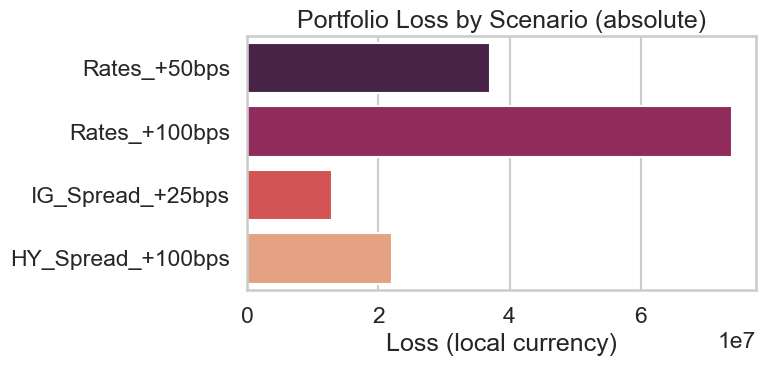

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sec, x="Sector_Loss", y="Sector", palette="mako")


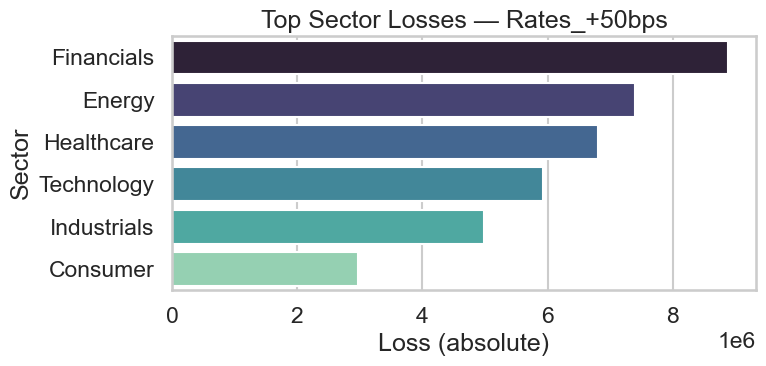

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sec, x="Sector_Loss", y="Sector", palette="mako")


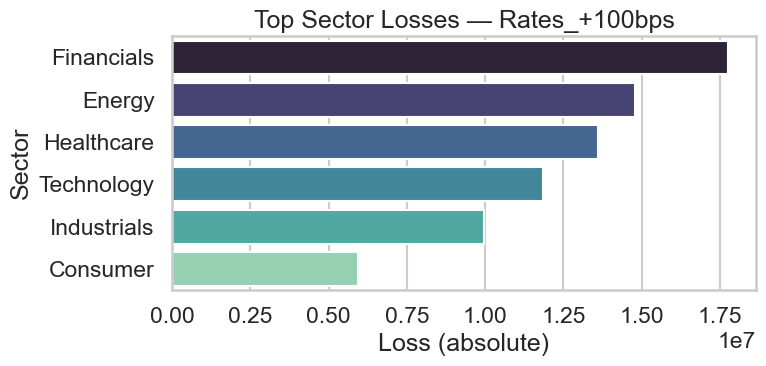

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sec, x="Sector_Loss", y="Sector", palette="mako")


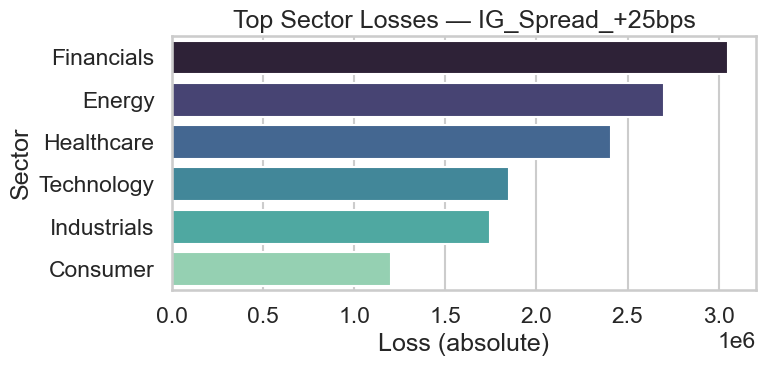

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sec, x="Sector_Loss", y="Sector", palette="mako")


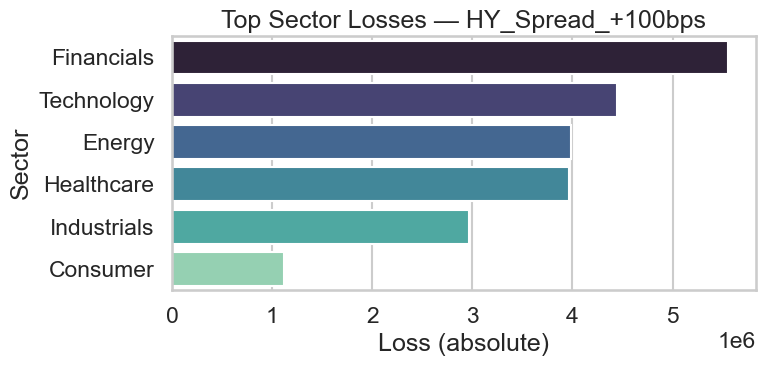

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rat, x="Rating_Loss", y="Rating", palette="flare")


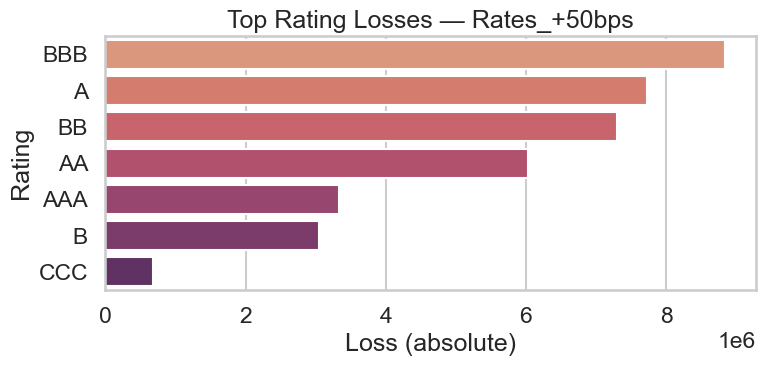

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rat, x="Rating_Loss", y="Rating", palette="flare")


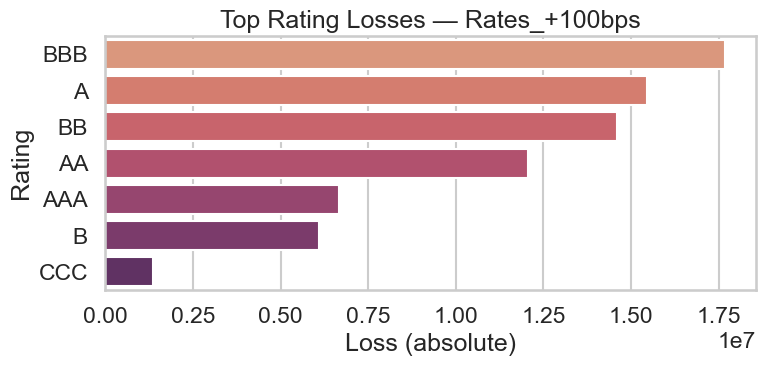

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rat, x="Rating_Loss", y="Rating", palette="flare")


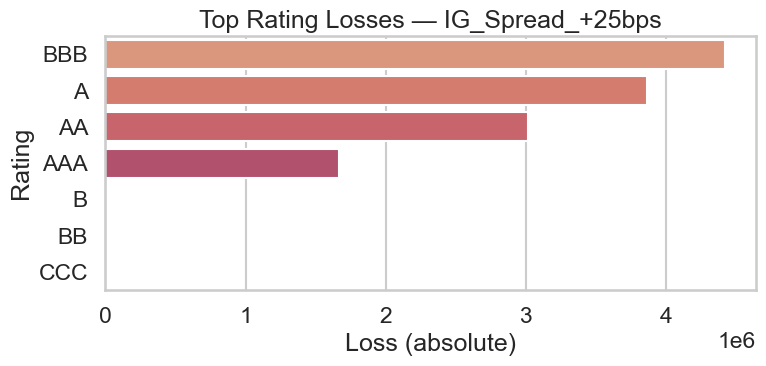

/var/folders/pk/_sj8msnd6058p2323ky_h2280000gn/T/ipykernel_39488/3841665602.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rat, x="Rating_Loss", y="Rating", palette="flare")


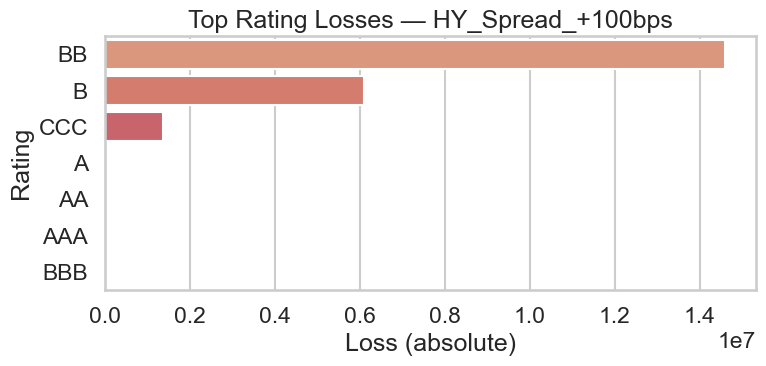

In [62]:
# Cell 14: charts for stress scenarios (inline)
plt.figure(figsize=(8,4))
names = list(portfolio_losses.keys())
vals = [portfolio_losses[n] for n in names]
sns.barplot(x=vals, y=names, palette="rocket")
plt.title("Portfolio Loss by Scenario (absolute)")
plt.xlabel("Loss (local currency)")
plt.tight_layout()
plt.show()

for name in loss_tables:
    sec = sector_losses[name].reset_index().sort_values("Sector_Loss", ascending=False).head(8)
    plt.figure(figsize=(8,4))
    sns.barplot(data=sec, x="Sector_Loss", y="Sector", palette="mako")
    plt.title(f"Top Sector Losses — {name}")
    plt.xlabel("Loss (absolute)")
    plt.tight_layout()
    plt.show()

for name in loss_tables:
    rat = rating_losses[name].reset_index().sort_values("Rating_Loss", ascending=False).head(8)
    plt.figure(figsize=(8,4))
    sns.barplot(data=rat, x="Rating_Loss", y="Rating", palette="flare")
    plt.title(f"Top Rating Losses — {name}")
    plt.xlabel("Loss (absolute)")
    plt.tight_layout()
    plt.show()

PHASE 6 – PERFORMANCE ATTRIBUTION

In [63]:
# Cell 15: ensure return columns and weights are present and normalized
required_cols = ["Bond_ID","Market_Value","Daily_Return","Benchmark_Return"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Required column missing: {c}")

# Ensure numeric
for c in ["Market_Value","Daily_Return","Benchmark_Return","Portfolio_Weight","Benchmark_Weight"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Compute or normalize weights if needed
if "Portfolio_Weight" not in df.columns or df["Portfolio_Weight"].isnull().all():
    df["Portfolio_Weight"] = df["Market_Value"] / df["Market_Value"].sum()
if "Benchmark_Weight" not in df.columns or df["Benchmark_Weight"].isnull().all():
    df["Benchmark_Weight"] = df["Market_Value"] / df["Market_Value"].sum()

# Convert percent weights to decimals if necessary
if 90 <= df["Portfolio_Weight"].sum() <= 110:
    df["Portfolio_Weight"] = df["Portfolio_Weight"] / 100.0
if 90 <= df["Benchmark_Weight"].sum() <= 110:
    df["Benchmark_Weight"] = df["Benchmark_Weight"] / 100.0

In [64]:
# Cell 16: compute portfolio and benchmark returns (single period)
portfolio_return = (df["Portfolio_Weight"] * df["Daily_Return"]).sum()
benchmark_return = (df["Benchmark_Weight"] * df["Benchmark_Return"]).sum()
excess_return = portfolio_return - benchmark_return

print("Portfolio Return (single period):", portfolio_return)
print("Benchmark Return (single period):", benchmark_return)
print("Excess Return (Portfolio - Benchmark):", excess_return)

Portfolio Return (single period): 0.0009155686103981754
Benchmark Return (single period): 6.51855566820023e-05
Excess Return (Portfolio - Benchmark): 0.0008503830537161731


In [65]:
# Cell 17: Brinson attribution function and sector attribution
def brinson_attribution(df, group_col, ret_col_port="Daily_Return", ret_col_bench="Benchmark_Return"):
    grp = df.groupby(group_col).apply(lambda g: pd.Series({
        "w_p": g["Portfolio_Weight"].sum(),
        "w_b": g["Benchmark_Weight"].sum(),
        "r_p": (g["Portfolio_Weight"] * g[ret_col_port]).sum() / max(g["Portfolio_Weight"].sum(), 1e-12),
        "r_b": (g["Benchmark_Weight"] * g[ret_col_bench]).sum() / max(g["Benchmark_Weight"].sum(), 1e-12)
    })).reset_index()
    r_b_total = (df["Benchmark_Weight"] * df["Benchmark_Return"]).sum()
    grp["Allocation"] = (grp["w_p"] - grp["w_b"]) * (grp["r_b"] - r_b_total)
    grp["Selection"] = grp["w_b"] * (grp["r_p"] - grp["r_b"])
    grp["Interaction"] = (grp["w_p"] - grp["w_b"]) * (grp["r_p"] - grp["r_b"])
    grp["Total_Contribution"] = grp["Allocation"] + grp["Selection"] + grp["Interaction"]
    return grp, r_b_total

sector_attr, bench_total = brinson_attribution(df, "Sector")
sector_attr = sector_attr.sort_values("Total_Contribution", ascending=False).reset_index(drop=True)
print("Sector attribution (Allocation, Selection, Interaction, Total_Contribution):")
display(sector_attr)
print("Benchmark total return used in allocation:", bench_total)

Sector attribution (Allocation, Selection, Interaction, Total_Contribution):


,Sector,w_p,w_b,r_p,r_b,Allocation,Selection,Interaction,Total_Contribution
0,Financials,0.233136,0.154707,0.001709,0.000325,0.000020,0.000214,0.000109,0.000343
1,Technology,0.188358,0.215122,0.002275,0.000452,-0.000010,0.000392,-0.000049,0.000333
2,Energy,0.161099,0.183786,-0.000770,-0.001693,0.000040,0.000170,-0.000021,0.000188
3,Healthcare,0.189449,0.211719,0.002419,0.001526,-0.000033,0.000189,-0.000020,0.000137
4,Consumer,0.084243,0.138200,-0.002113,-0.000942,0.000054,-0.000162,0.000063,-0.000044
5,Industrials,0.143716,0.096465,-0.000470,0.000371,0.000014,-0.000081,-0.000040,-0.000106


Benchmark total return used in allocation: 6.51855566820023e-05


In [66]:
# Cell 18: rating and country attribution
if "Rating" in df.columns:
    rating_attr, _ = brinson_attribution(df, "Rating")
    rating_attr = rating_attr.sort_values("Total_Contribution", ascending=False).reset_index(drop=True)
    print("Rating attribution:")
    display(rating_attr)
else:
    print("Rating column not present; skipping rating attribution.")

if "Country" in df.columns:
    country_attr, _ = brinson_attribution(df, "Country")
    country_attr = country_attr.sort_values("Total_Contribution", ascending=False).reset_index(drop=True)
    print("Country attribution (top 20):")
    display(country_attr.head(20))
else:
    print("Country column not present; skipping country attribution.")

Rating attribution:


,Rating,w_p,w_b,r_p,r_b,Allocation,Selection,Interaction,Total_Contribution
0,BB,0.185909,0.184846,0.003941,-0.000833,-9.548766e-07,0.000883,0.000005,0.000887
1,A,0.204547,0.183384,0.002203,0.000133,1.431210e-06,0.000380,0.000044,0.000425
2,AA,0.157672,0.186867,0.001273,-0.000312,1.100357e-05,0.000296,-0.000046,0.000261
3,CCC,0.027699,0.049316,0.000115,-0.002378,5.282333e-05,0.000123,-0.000054,0.000122
4,B,0.079188,0.055030,0.001352,0.001016,2.297400e-05,0.000018,0.000008,0.000050
5,AAA,0.101954,0.131322,-0.000600,0.000600,-1.569754e-05,-0.000158,0.000035,-0.000138
6,BBB,0.243031,0.209234,-0.002129,0.001126,3.586056e-05,-0.000681,-0.000110,-0.000755


Country attribution (top 20):


,Country,w_p,w_b,r_p,r_b,Allocation,Selection,Interaction,Total_Contribution
0,UK,0.160286,0.207976,0.000292,-0.003477,0.000169,0.000784,-0.000180,0.000773
1,Canada,0.154577,0.163633,0.004838,0.002027,-0.000018,0.000460,-0.000025,0.000417
2,US,0.177908,0.131994,0.002231,0.000213,0.000007,0.000266,0.000093,0.000366
3,France,0.106325,0.122542,-0.001154,-0.001702,0.000029,0.000067,-0.000009,0.000087
4,Australia,0.149953,0.116869,0.002433,0.002926,0.000095,-0.000058,-0.000016,0.000021
5,Germany,0.129333,0.142473,-0.000514,0.001477,-0.000019,-0.000284,0.000026,-0.000276
6,Japan,0.121618,0.114513,-0.003714,0.000740,0.000005,-0.000510,-0.000032,-0.000537


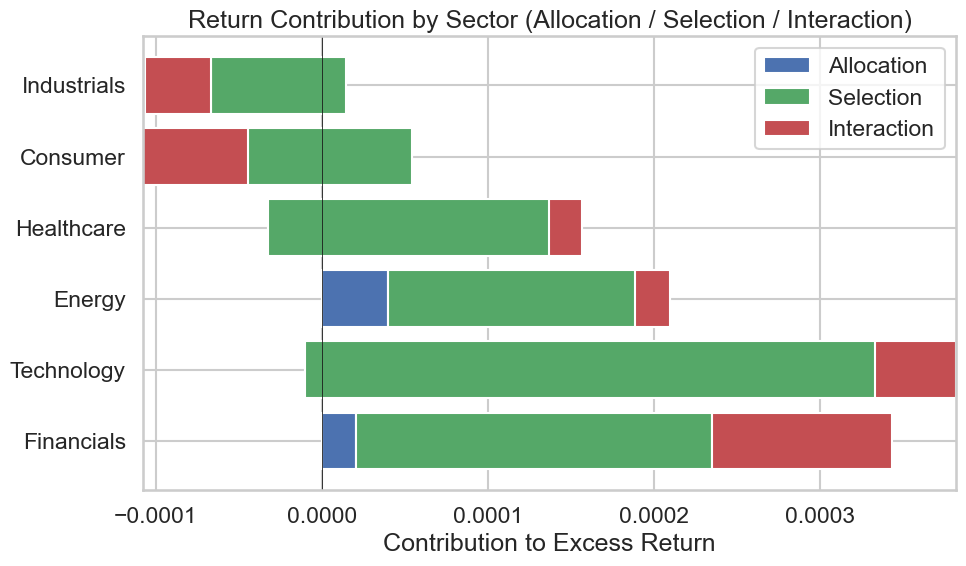

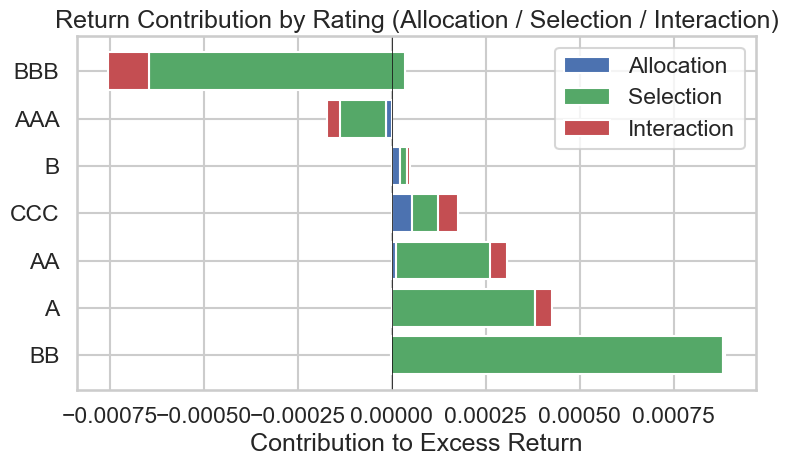

In [67]:
# Cell 19: contribution charts (inline)
plt.rcParams.update({'figure.max_open_warning': 0})

# Sector stacked contribution
sector_plot = sector_attr.copy().sort_values("Total_Contribution", ascending=False).head(12)
plt.figure(figsize=(10,6))
bottom = np.zeros(len(sector_plot))
for col, color in zip(["Allocation","Selection","Interaction"], ["#4C72B0","#55A868","#C44E52"]):
    plt.barh(sector_plot["Sector"], sector_plot[col], left=bottom, color=color, label=col)
    bottom = bottom + sector_plot[col].values
plt.axvline(0, color="k", linewidth=0.6)
plt.title("Return Contribution by Sector (Allocation / Selection / Interaction)")
plt.xlabel("Contribution to Excess Return")
plt.legend()
plt.tight_layout()
plt.show()

# Rating stacked contribution if available
if "Rating" in df.columns:
    rating_plot = rating_attr.copy().sort_values("Total_Contribution", ascending=False)
    plt.figure(figsize=(8,5))
    bottom = np.zeros(len(rating_plot))
    for col, color in zip(["Allocation","Selection","Interaction"], ["#4C72B0","#55A868","#C44E52"]):
        plt.barh(rating_plot["Rating"], rating_plot[col], left=bottom, color=color, label=col)
        bottom = bottom + rating_plot[col].values
    plt.axvline(0, color="k", linewidth=0.6)
    plt.title("Return Contribution by Rating (Allocation / Selection / Interaction)")
    plt.xlabel("Contribution to Excess Return")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [68]:
# Cell 20: quick summaries to answer the questions
print("Portfolio Return:", portfolio_return)
print("Benchmark Return:", benchmark_return)
print("Excess Return:", excess_return)

print("\nTop sectors that helped (positive Total_Contribution):")
display(sector_attr[sector_attr["Total_Contribution"]>0].head(10)[["Sector","Allocation","Selection","Interaction","Total_Contribution"]])

print("\nTop sectors that hurt (negative Total_Contribution):")
display(sector_attr[sector_attr["Total_Contribution"]<0].head(10)[["Sector","Allocation","Selection","Interaction","Total_Contribution"]])

Portfolio Return: 0.0009155686103981754
Benchmark Return: 6.51855566820023e-05
Excess Return: 0.0008503830537161731

Top sectors that helped (positive Total_Contribution):


,Sector,Allocation,Selection,Interaction,Total_Contribution
0,Financials,0.000020,0.000214,0.000109,0.000343
1,Technology,-0.000010,0.000392,-0.000049,0.000333
2,Energy,0.000040,0.000170,-0.000021,0.000188
3,Healthcare,-0.000033,0.000189,-0.000020,0.000137



Top sectors that hurt (negative Total_Contribution):


,Sector,Allocation,Selection,Interaction,Total_Contribution
4,Consumer,0.000054,-0.000162,0.000063,-0.000044
5,Industrials,0.000014,-0.000081,-0.000040,-0.000106


DONE